In [ ]:
### Project: Ethereum Fraud Detection

This project focuses on detecting fraudulent Ethereum wallet activity using real-world transaction data. The goal is to help crypto platforms prioritize suspicious users for manual review using machine learning, especially under data imbalance and operational constraints.



In [33]:
!pip install xgboost
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load data
df = pd.read_csv("data/transaction_dataset.csv")

# Quick preview
df.head()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


Logistic Regression 每折 F1-score：[0.37338262 0.43507589 0.29378531 0.40145985 0.42805755]
Logistic Regression 平均 F1-score：0.3864

Random Forest 每折 F1-score：[0.8962149  0.89901478 0.90123457 0.91108404 0.90528905]
Random Forest 平均 F1-score：0.9026

XGBoost 每折 F1-score：[0.92342857 0.92237443 0.93287037 0.94036697 0.92740047]
XGBoost 平均 F1-score：0.9293



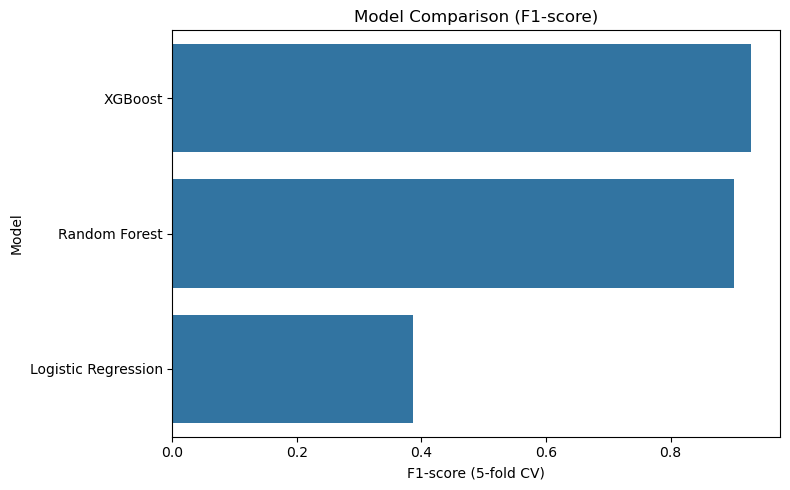

In [37]:
df_clean = df.drop(columns=['Unnamed: 0', 'Index', 'Address'], errors='ignore')

non_numeric_cols = df_clean.select_dtypes(include='object').columns.tolist()
df_clean = df_clean.drop(columns=non_numeric_cols)

X = df_clean.drop(columns=['FLAG'], errors='ignore')
y = df_clean['FLAG']
X = X.fillna(0)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear'),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
        eval_metric='logloss',
        random_state=42
    )
}

model_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, scoring='f1', cv=cv)
    model_scores[name] = scores
    print(f"{name} 每折 F1-score：{scores}")
    print(f"{name} 平均 F1-score：{scores.mean():.4f}\n")

avg_scores = {name: np.mean(score) for name, score in model_scores.items()}
score_df = pd.DataFrame.from_dict(avg_scores, orient='index', columns=['Avg F1-score'])
score_df = score_df.sort_values(by='Avg F1-score', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=score_df, x='Avg F1-score', y=score_df.index)
plt.title('Model Comparison (F1-score)')
plt.xlabel('F1-score (5-fold CV)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

🔍 Precision@Top 50: 100.00%
🔍 Precision@Top 100: 100.00%
🔍 Precision@Top 150: 100.00%
🔍 Precision@Top 200: 100.00%
🔍 Precision@Top 250: 100.00%
🔍 Precision@Top 300: 100.00%
🔍 Precision@Top 350: 99.14%
🔍 Precision@Top 400: 96.75%
🔍 Precision@Top 450: 90.44%
🔍 Precision@Top 500: 84.00%
🔍 Precision@Top 550: 77.09%
🔍 Precision@Top 600: 71.00%
🔍 Precision@Top 650: 66.00%
🔍 Precision@Top 700: 61.29%
🔍 Precision@Top 750: 57.33%
🔍 Precision@Top 800: 54.00%
🔍 Precision@Top 850: 50.94%
🔍 Precision@Top 900: 48.44%
🔍 Precision@Top 950: 45.89%
🔍 Precision@Top 1000: 43.60%


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


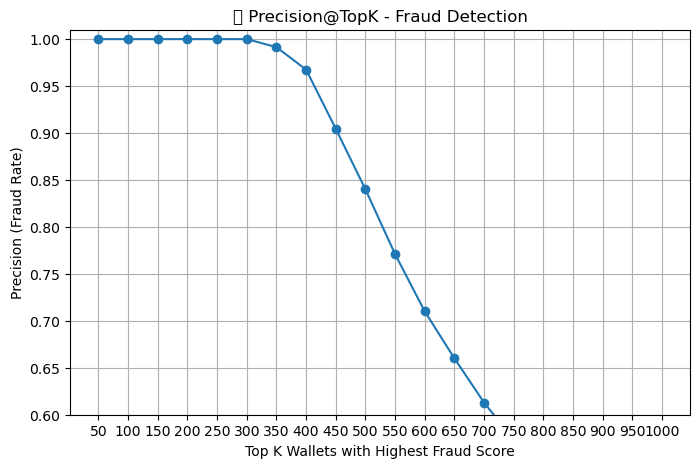

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

final_model = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)
final_model.fit(X_train, y_train)

y_proba = final_model.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df['fraud_score'] = y_proba
risk_df['actual'] = y_test.values

top_ks = list(range(50, 1001, 50))  
precisions = []

for k in top_ks:
    topk = risk_df.sort_values(by='fraud_score', ascending=False).head(k)
    precision_k = (topk['actual'] == 1).mean()
    precisions.append(precision_k)
    print(f"🔍 Precision@Top {k}: {precision_k:.2%}")

plt.figure(figsize=(8,5))
plt.plot(top_ks, precisions, marker='o')
plt.title('📊 Precision@TopK - Fraud Detection')
plt.xlabel('Top K Wallets with Highest Fraud Score')
plt.ylabel('Precision (Fraud Rate)')
plt.grid(True)
plt.xticks(top_ks)
plt.ylim(0.6, 1.01)
plt.show()


In [ ]:
### Conclusion

This project shows that with a well-designed ML pipeline, it is possible to accurately detect fraud in Ethereum wallet activity using imbalanced, real-world data. Precision@TopK analysis reveals that our model can help fraud teams focus on the most suspicious users, saving time and improving effectiveness.

### Future Work

- Incorporate temporal patterns of transactions
- Add address network graph features (e.g. betweenness, connected wallets)
- Try anomaly detection methods for unseen fraud types (unsupervised learning)
